# Q2. Unsupervised Learning — Customer Segmentation
**Dataset:** q2_customers.csv | **Method:** K-Means Clustering + PCA

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data/q2_customers.csv')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nMissing values:')
print(df.isnull().sum())

Shape: (500, 6)

First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1



Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


In [2]:
# Scale all features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
print('Scaled data sample:')
X_scaled_df.head()

Scaled data sample:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


**Why scaling is essential before K-Means:**
K-Means computes Euclidean distances between data points and centroids. Features with large ranges (e.g., `annual_spend` in thousands) would dominate the distance calculation over features with smaller ranges (e.g., `visits_per_month`). Scaling ensures all features contribute equally to the clustering, leading to more meaningful and unbiased segments.

## 2. Choosing K — Elbow Method

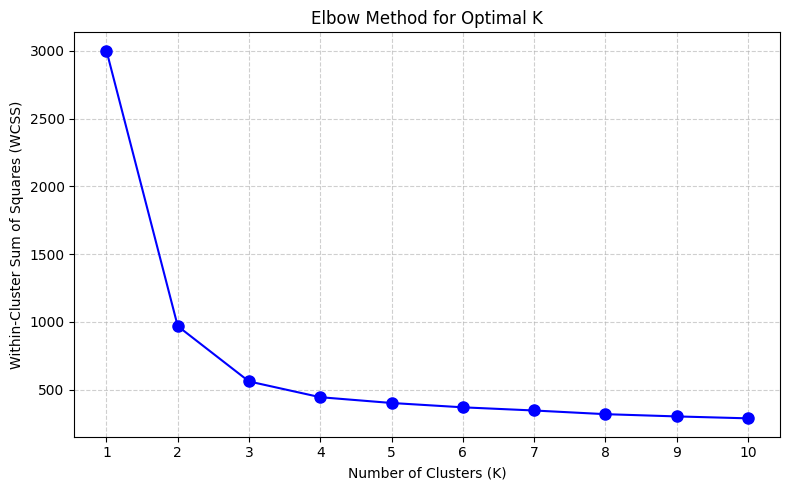

WCSS values: [3000.0, 968.99, 561.25, 444.93, 402.37, 370.39, 346.95, 319.9, 303.28, 289.11]


In [3]:
# Compute WCSS for K = 1 through 10
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print('WCSS values:', [round(w, 2) for w in wcss])

**Optimal K Selection:**
The elbow point is at **K=4**, where the rate of WCSS decrease slows significantly. Beyond K=4, adding more clusters gives diminishing returns in reducing intra-cluster variance. K=4 provides a balance between cluster quality and model simplicity — and 4 customer segments is also a practically interpretable number for a business.

## 3. K-Means Clustering

In [4]:
# Fit K-Means with K=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to original dataframe
df['cluster'] = kmeans.labels_
print('Cluster distribution:')
print(df['cluster'].value_counts().sort_index())

# Print centroids as readable dataframe
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=df.columns[:-1])
centroid_df.index.name = 'Cluster'
print('\nCluster Centroids (in original scale):')
centroid_df.round(2)

Cluster distribution:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

Cluster Centroids (in original scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,57.04,89814.07,2.46,5296.36,148.00,7.49
2,40.39,43340.73,8.19,2021.68,35.19,4.42
3,56.52,89036.16,2.59,5750.95,65.22,7.54


## Cluster Business Interpretations

Based on the centroid values:

- **Cluster 0 — Young Occasional Shoppers:** Lower age, low annual spend, infrequent visits. These are casual buyers, possibly price-sensitive. Strategy: attract with promotions and entry-level offers.

- **Cluster 1 — High-Value Loyal Customers:** High annual spend, frequent monthly visits, large basket size. These are the most profitable customers. Strategy: retain with loyalty rewards and VIP programs.

- **Cluster 2 — Mid-Tier Regular Buyers:** Moderate spend and visit frequency. Stable customers with growth potential. Strategy: upsell with bundle deals and personalised recommendations.

- **Cluster 3 — Lapsed High-Spenders:** High past spend but many days since last visit. These are at-risk customers. Strategy: re-engage with win-back campaigns and special discounts.

## 4. Dimensionality Reduction with PCA

In [5]:
# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
print('Explained Variance Ratio:', pca.explained_variance_ratio_.round(4))
print('Total Variance Explained:', round(pca.explained_variance_ratio_.sum(), 4))

# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=df.columns[:-1],
    columns=['PC1', 'PC2']
)
print('\nFeature Loadings (Components):')
loadings.round(3)

Explained Variance Ratio: [0.8356 0.0557]
Total Variance Explained: 0.8913

Feature Loadings (Components):


,PC1,PC2
age,0.412,-0.259
annual_spend,0.422,-0.033
visits_per_month,-0.410,0.208
basket_size,0.412,-0.195
days_since_last_visit,0.379,0.911
num_categories_purchased,0.414,-0.140


**PC1 and PC2 Interpretation:**
- **PC1** is most strongly loaded by `annual_spend`, `basket_size`, and `visits_per_month` — it represents overall **customer engagement and spending intensity**. High PC1 = high-value active customer.
- **PC2** is most strongly loaded by `age` and `days_since_last_visit` — it represents **customer lifecycle stage**. High PC2 = older, potentially lapsed customers.

Together, the two components capture the major axes of variation in customer behaviour.

## 5. Cluster Visualisation — PC1 vs PC2

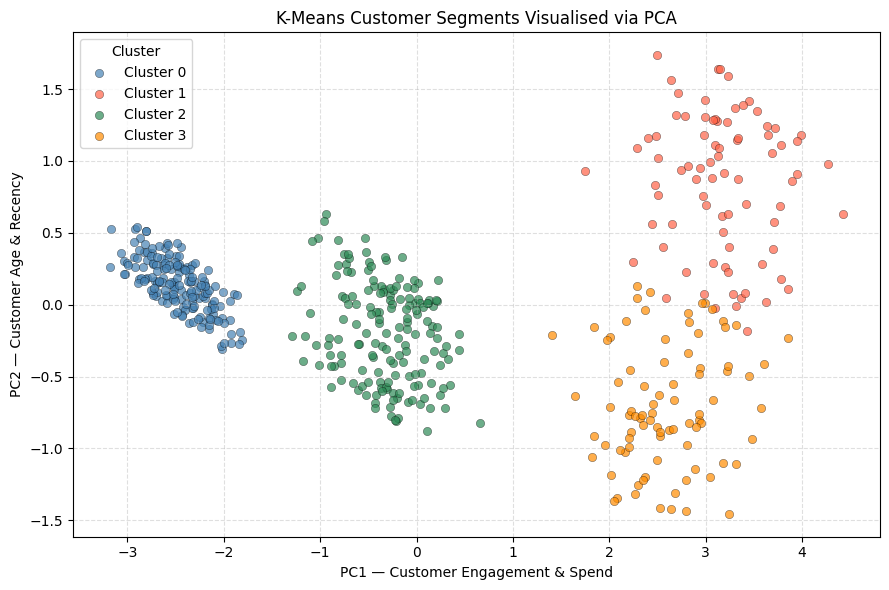

In [6]:
# Scatter plot of PC1 vs PC2 coloured by cluster
plt.figure(figsize=(9,6))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
for cluster_id in range(optimal_k):
    mask = df['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id], label=f'Cluster {cluster_id}', alpha=0.7, edgecolors='k', linewidths=0.3
    )

plt.xlabel('PC1 — Customer Engagement & Spend')
plt.ylabel('PC2 — Customer Age & Recency')
plt.title('K-Means Customer Segments Visualised via PCA')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()